Saving Best Movie by Year Netflix.csv to Best Movie by Year Netflix (17).csv
Shape: (49, 6)

Columns:
Index(['index', 'TITLE', 'RELEASE_YEAR', 'SCORE', 'MAIN_GENRE',
       'MAIN_PRODUCTION'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            49 non-null     int64  
 1   TITLE            49 non-null     object 
 2   RELEASE_YEAR     49 non-null     int64  
 3   SCORE            49 non-null     float64
 4   MAIN_GENRE       49 non-null     object 
 5   MAIN_PRODUCTION  49 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 2.4+ KB
index              0
TITLE              0
RELEASE_YEAR       0
SCORE              0
MAIN_GENRE         0
MAIN_PRODUCTION    0
dtype: int64


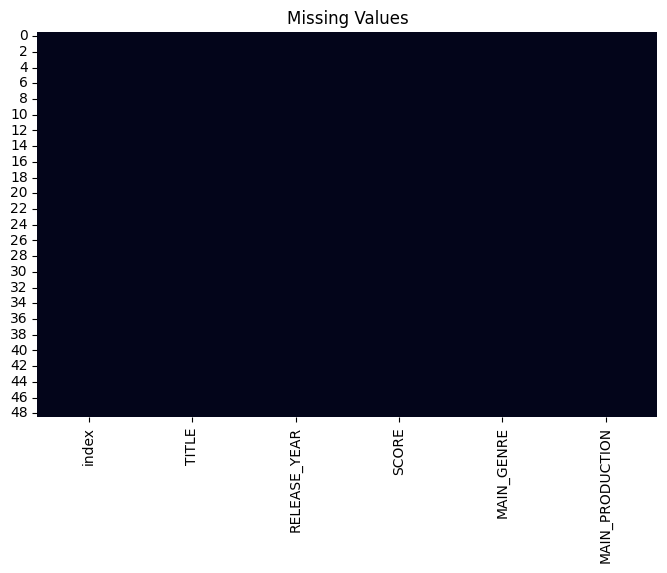

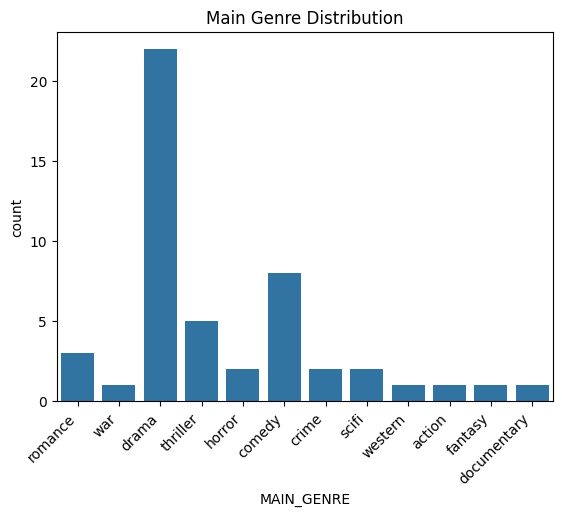

MAIN_GENRE
drama          22
comedy          8
thriller        5
romance         3
crime           2
horror          2
scifi           2
war             1
western         1
action          1
fantasy         1
documentary     1
Name: count, dtype: int64


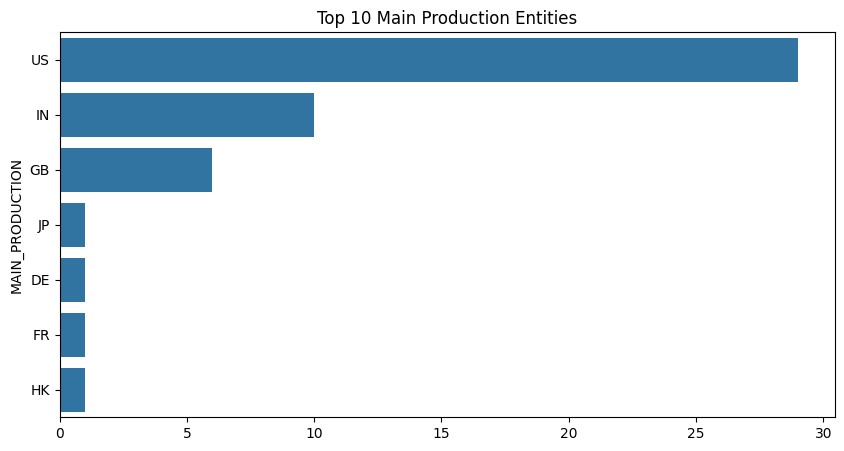

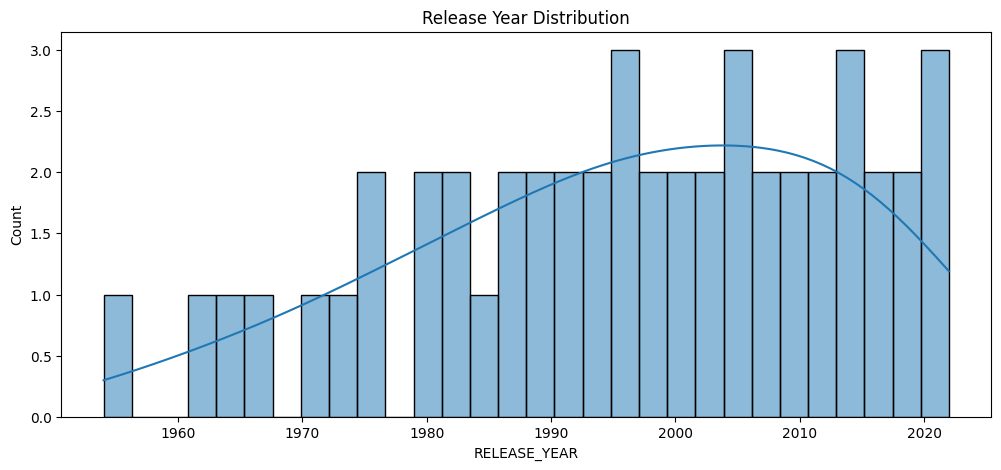

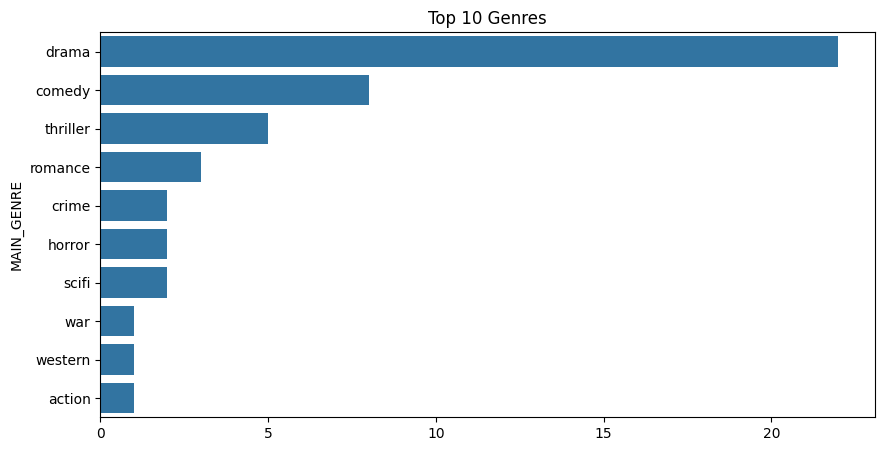

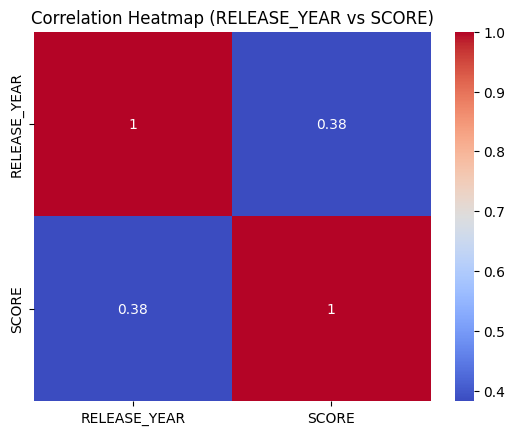

In [28]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv('Best Movie by Year Netflix.csv')
df.head()
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.info()
import seaborn as sns
import matplotlib.pyplot as plt

print(df.isnull().sum())

plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()
# Correcting the column name for countplot
sns.countplot(data=df, x='MAIN_GENRE')
plt.title("Main Genre Distribution")
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.show()

print(df['MAIN_GENRE'].value_counts())
# The 'country' column does not exist. Using 'MAIN_PRODUCTION' instead.
country_production = df['MAIN_PRODUCTION'].dropna().str.split(', ').explode()

top_country_production = country_production.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_country_production.values, y=top_country_production.index)
plt.title("Top 10 Main Production Entities")
plt.show()
plt.figure(figsize=(12,5))
sns.histplot(df['RELEASE_YEAR'], bins=30, kde=True)
plt.title("Release Year Distribution")
plt.show()
# Correcting 'listed_in' to 'MAIN_GENRE' and removing unnecessary split/explode
genres = df['MAIN_GENRE']

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres")
plt.show()
# The 'rating' column does not exist in this DataFrame. Removing this plot for now.
# plt.figure(figsize=(10,5))
# sns.countplot(y=df['rating'],
#               order=df['rating'].value_counts().index)
# plt.title("Content Ratings")
# plt.show()

# The 'type' and 'duration' columns do not exist in this DataFrame.
# Assuming all entries are movies based on the dataset name.
# Using 'RELEASE_YEAR' and 'SCORE' for correlation plot as they are numeric.
movies_for_corr = df[['RELEASE_YEAR', 'SCORE']].copy()

corr = movies_for_corr.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (RELEASE_YEAR vs SCORE)")
plt.show()

# The 'type' column does not exist in this DataFrame.
# It appears this dataset only contains movies.
# import matplotlib.pyplot as plt

# content_type = df['type'].value_counts()

# plt.figure(figsize=(6,6))
# plt.pie(content_type,
#         labels=content_type.index,
#         autopct='%1.1f%%',
#         startangle=90)

# plt.title('Distribution of Movies and TV Shows')
# plt.show()

In [8]:
file_path = 'netflix_titles.csv (1).ipynb'
try:
    with open(file_path, 'r') as f:
        for i, line in enumerate(f):
            if i >= 10: # Displaying first 10 lines to avoid overwhelming output
                break
            print(line.strip())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

{
"cells": [
{
"cell_type": "markdown",
"metadata": {},
"source": [
"# Netflix Shows and Movies - Exploratory Analysis\n",
"\n",
"The dataset consists of meta details about the movies and tv shows such as the title, director, and cast of the shows / movies. Details such as the release year, the rating, duration etc. As the first step, let's load the dataset, create some new features. In this kernel, I have analysed this dataset to find top insights and findings. \n",
"\n",
